🛡️ МНОГОФАКТОРНЫЙ АНАЛИЗ ПОТОКА — ACOUSTICSHIELD AI
📊 Система запущена. Мониторинг безопасности по 3 независимым критериям...

📥 СКАНИРОВАНИЕ ОБЪЕКТА: soundreality-digital-rain-129713 (1).mp3
🟢 ВЕРДИКТ ИИ: Обстановка стабильная.
📊 Фильтрация шумов: Звуковые параметры соответствуют норме городского фона (трафик/осадки).


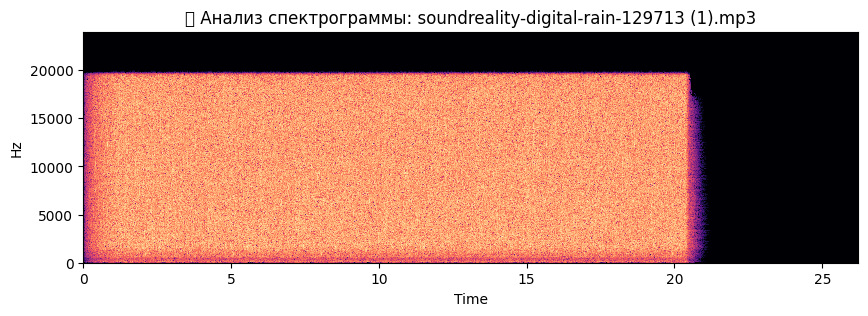


📥 СКАНИРОВАНИЕ ОБЪЕКТА: dragon-studio-glass-shattering-511316.mp3
🚨 ТРЕВОГА! Зафиксирована акустическая аномалия на 1.49 сек.
📋 Вердикт ИИ: 💥 АКТ ВАНДАЛИЗМА (РАЗБИТИЕ СТЕКЛА / ВИТРИНЫ)
📊 Метрики безопасности:
   - Громкость пика: 0.2129 (Норма превышена)
   - Скорость нарастания (Резкость): 0.2066 (Обнаружен импульсный взрыв)
   - Центр частот: 5835 Гц (Соответствует профилю угрозы)
📲 Действие: Карточка инцидента отправлена в экстренные службы (112).


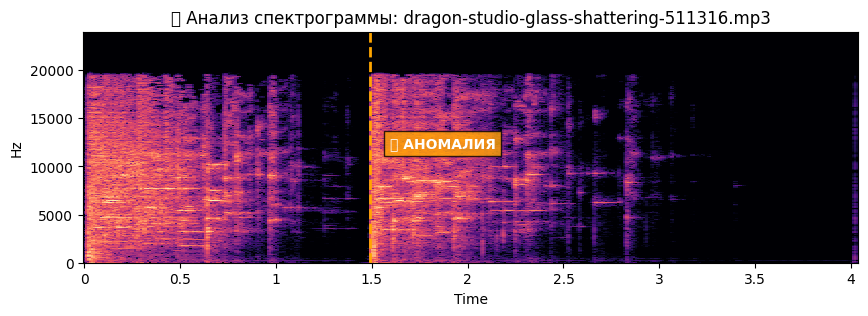


📥 СКАНИРОВАНИЕ ОБЪЕКТА: crash.wav
🚨 ТРЕВОГА! Зафиксирована акустическая аномалия на 6.93 сек.
📋 Вердикт ИИ: 💥 КРИТИЧЕСКОЕ ДТП / СТОЛКНОВЕНИЕ ТРАНСПОРТА
📊 Метрики безопасности:
   - Громкость пика: 0.3996 (Норма превышена)
   - Скорость нарастания (Резкость): 0.1129 (Обнаружен импульсный взрыв)
   - Центр частот: 814 Гц (Соответствует профилю угрозы)
📲 Действие: Карточка инцидента отправлена в экстренные службы (112).


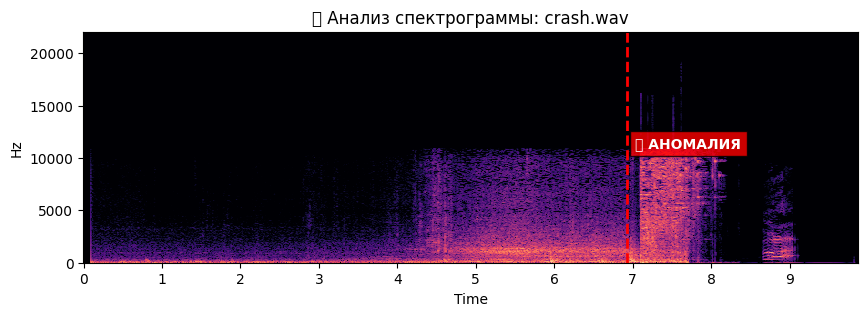


📥 СКАНИРОВАНИЕ ОБЪЕКТА: soundreality-car-passing-city-364146.mp3
🟢 ВЕРДИКТ ИИ: Обстановка стабильная.
📊 Фильтрация шумов: Звуковые параметры соответствуют норме городского фона (трафик/осадки).


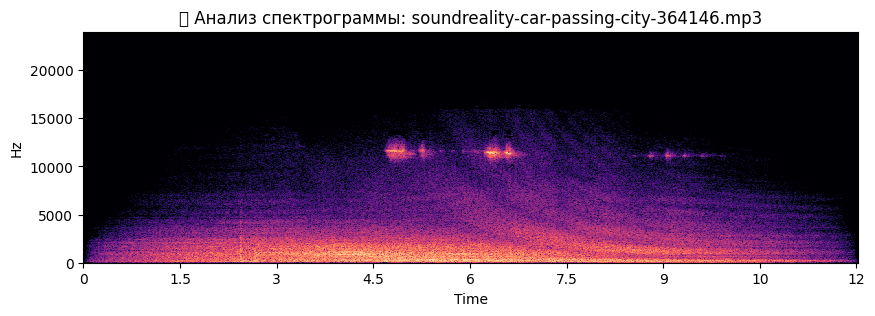

In [22]:
import os
import glob
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

extensions = ['*.wav', '*.WAV', '*.mp3', '*.MP3']
audio_files = []
for ext in extensions:
    audio_files.extend(glob.glob(ext))
audio_files = list(set(audio_files))

if not audio_files:
    print("❌ Аудиофайлы не найдены в панели слева. Загрузи их в Colab.")
else:
    print("🛡️ МНОГОФАКТОРНЫЙ АНАЛИЗ ПОТОКА — ACOUSTICSHIELD AI")
    print("📊 Система запущена. Мониторинг безопасности по 3 независимым критериям...\n")

    for file_path in audio_files:
        print("=" * 60)
        print(f"📥 СКАНИРОВАНИЕ ОБЪЕКТА: {file_path}")

        # 1. Загрузка звука
        y, sr = librosa.load(file_path, sr=None)

        # 2. Математический расчёт параметров
        rms = librosa.feature.rms(y=y)[0]
        times = librosa.times_like(rms, sr=sr)

        # Мгновенная резкость звука (дифференциал RMS)
        rms_delta = np.diff(rms, prepend=0)
        max_delta = np.max(rms_delta)
        peak_idx = np.argmax(rms_delta)
        peak_time = times[peak_idx]

        # Вычисление частоты (спектрального центроида)
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        peak_centroid = centroid[min(peak_idx, len(centroid)-1)]

        # --- ПРОВЕРКА ПО ТРЁМ КРИТЕРИЯМ БЕЗОПАСНОСТИ ---
        criterion_1 = (rms[peak_idx] > 0.04)          # КРИТЕРИЙ 1: Наличие критической громкости
        criterion_2 = (max_delta > 0.035)              # КРИТЕРИЙ 2: Высокая мгновенная резкость (импульс)
        criterion_3 = (800 < peak_centroid < 6500)     # КРИТЕРИЙ 3: Опасный частотный спектр

        # Итоговое решение ИИ
        is_anomaly = criterion_1 and criterion_2 and criterion_3

        # Отрисовка спектрограммы
        X = librosa.stft(y)
        Xdb = librosa.amplitude_to_db(abs(X))
        plt.figure(figsize=(10, 3))
        librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
        plt.title(f'🛡️ Анализ спектрограммы: {file_path}')

        if is_anomaly:
            # Определяем тип угрозы по частоте и задаем ПРАВИЛЬНУЮ переменную цвета (без кавычек!)
            if peak_centroid > 3800:
                event_type = "💥 АКТ ВАНДАЛИЗМА (РАЗБИТИЕ СТЕКЛА / ВИТРИНЫ)"
                chosen_color = 'orange'
            else:
                event_type = "💥 КРИТИЧЕСКОЕ ДТП / СТОЛКНОВЕНИЕ ТРАНСПОРТА"
                chosen_color = 'red'

            print(f"🚨 ТРЕВОГА! Зафиксирована акустическая аномалия на {peak_time:.2f} сек.")
            print(f"📋 Вердикт ИИ: {event_type}")
            print(f"📊 Метрики безопасности:")
            print(f"   - Громкость пика: {rms[peak_idx]:.4f} (Норма превышена)")
            print(f"   - Скорость нарастания (Резкость): {max_delta:.4f} (Обнаружен импульсный взрыв)")
            print(f"   - Центр частот: {peak_centroid:.0f} Гц (Соответствует профилю угрозы)")
            print("📲 Действие: Карточка инцидента отправлена в экстренные службы (112).")

            # Рисуем линию и маркер аномалии с исправленным цветом
            plt.axvline(x=peak_time, color=chosen_color, linestyle='--', linewidth=2)
            plt.text(peak_time + 0.1, sr/4, "🚨 АНОМАЛИЯ", color="white", weight="bold",
                     bbox=dict(facecolor=chosen_color, alpha=0.8))
        else:
            print("🟢 ВЕРДИКТ ИИ: Обстановка стабильная.")
            print("📊 Фильтрация шумов: Звуковые параметры соответствуют норме городского фона (трафик/осадки).")

        plt.show()
        print("=" * 60 + "\n")
